# **Installation and Dependencies:**

Since we are adding TRPO and QR-DQN, we must install the sb3-contrib package.

In [1]:
# Block 1: Install SB3 and Contrib (Required for TRPO and QR-DQN)
!pip install stable-baselines3[extra] sb3-contrib gymnasium shimmy matplotlib pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.2/93.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 8.4 MB/s eta 0:00:00


# **The Continuous Market Environment:**

We will use the Toxic Flow environment logic for these tests, as it provides the most challenging "Real World" scenario for the agents to learn .

In [8]:
import gymnasium as gym
import numpy as np
import pandas as pd
from gymnasium import spaces

class ContinuousMarketEnv(gym.Env):
    def __init__(self, n_steps=1000):
        super().__init__()
        self.df = pd.DataFrame({
            'mid': 100 + np.cumsum(np.random.normal(0, 0.2, n_steps)),
            'toxicity': np.random.uniform(0, 1, n_steps)
        })
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(3,), dtype=np.float32)
        self.action_space = spaces.Box(low=0.0, high=2.5, shape=(2,), dtype=np.float32)
        self.reset()

    def reset(self, seed=None, options=None):
        # REQUIRED: Modern Gymnasium reset signature
        super().reset(seed=seed)
        self.idx, self.inventory, self.cash = 0, 0, 0.0
        return self._get_obs(), {}

    def _get_obs(self):
        row = self.df.iloc[self.idx]
        return np.array([row['mid'], self.inventory, row['toxicity']], dtype=np.float32)

    def step(self, action):
        bid_d, ask_d = action
        row = self.df.iloc[self.idx]

        # Adverse Selection Logic [cite: 72, 280]
        if row['toxicity'] > 0.85:
            price_impact = -0.75 # Toxic drop
            self.inventory += 1; self.cash -= (row['mid'] - bid_d)
        else:
            price_impact = np.random.normal(0, 0.05)
            if np.random.random() < (0.5 - bid_d*0.2): self.inventory += 1; self.cash -= (row['mid'] - bid_d)
            if np.random.random() < (0.5 - ask_d*0.2): self.inventory -= 1; self.cash += (row['mid'] + ask_d)

        self.idx += 1
        wealth = self.cash + (self.inventory * (row['mid'] + price_impact))
        reward = wealth - 0.5 * (self.inventory ** 2) # Inventory Penalty [cite: 58, 260]

        done = (self.idx >= len(self.df) - 1)
        return self._get_obs(), float(reward), done, False, {"wealth": wealth}

# **Discrete Environment Wrapper (for DQN/QR-DQN):**

Q-Learning algorithms like DQN require a Discrete action space. This wrapper converts your continuous spreads into 5 fixed levels (0.5, 1.0, 1.5, 2.0, 2.5 ticks).

In [9]:
class DiscreteMarketWrapper(gym.ActionWrapper):
    def __init__(self, env):
        super().__init__(env)
        # 5 levels for bid and 5 for ask = 25 combinations
        self.action_space = spaces.Discrete(25)
        self.spread_levels = [0.5, 1.0, 1.5, 2.0, 2.5]

    def action(self, action):
        bid_idx = action // 5
        ask_idx = action % 5
        return np.array([self.spread_levels[bid_idx], self.spread_levels[ask_idx]], dtype=np.float32)

# **Training Block (Continuous Agents):**

This block trains TD3, DDPG, A2C, and TRPO.

In [10]:
from stable_baselines3 import PPO, SAC, TD3, DDPG, A2C
from sb3_contrib import TRPO

env_c = ContinuousMarketEnv()

print("Training Continuous Agents...")
model_ppo = PPO("MlpPolicy", env_c, verbose=0).learn(total_timesteps=10000)
model_sac = SAC("MlpPolicy", env_c, verbose=0).learn(total_timesteps=10000)
model_td3 = TD3("MlpPolicy", env_c, verbose=0).learn(total_timesteps=10000)
model_ddpg = DDPG("MlpPolicy", env_c, verbose=0).learn(total_timesteps=10000)
model_a2c = A2C("MlpPolicy", env_c, verbose=0).learn(total_timesteps=10000)
model_trpo = TRPO("MlpPolicy", env_c, verbose=0).learn(total_timesteps=10000)
print("Continuous Training Complete.")

Training Continuous Agents...
Continuous Training Complete.


# **Training Block (Discrete & Distributional Agents):**

This block trains DQN and QR-DQN using the discrete wrapper.

In [12]:
from stable_baselines3 import DQN
from sb3_contrib import QRDQN

env_d = DiscreteMarketWrapper(ContinuousMarketEnv())

print("Training Discrete Agents...")
model_dqn = DQN("MlpPolicy", env_d, verbose=0).learn(total_timesteps=15000)
model_qrdqn = QRDQN("MlpPolicy", env_d, verbose=0).learn(total_timesteps=15000)
print("Discrete Training Complete.")

Training Discrete Agents...
Discrete Training Complete.


# **The Evaluation Baselines**

As required by our project criteria, we must compare the RL agents against a Random Policy, a Fixed Spread Strategy, and the Avellaneda-Stoikov (A&S) mathematical model.

In [18]:
# Block 7: Theoretical Baselines
class RandomAgent:
    def predict(self, obs, deterministic=True):
        # Returns a simple array of 2 depths
        return np.random.uniform(0, 2.5, size=(2,)), None

class FixedAgent:
    def predict(self, obs, deterministic=True):
        # Returns a simple array
        return np.array([1.0, 1.0]), None

class ASAgent:
    def predict(self, obs, deterministic=True):
        s, q, t = obs[0], obs[1], obs[2]
        # Reservation price: r = s - q * gamma * sigma^2 * (T - t) [cite: 38, 144, 246]
        res_price = s - (q * 0.1 * (0.2**2) * (1.0 - t))
        # Optimal spread: delta = gamma * sigma^2 * (T-t) + (2/gamma) * ln(1 + gamma/k) [cite: 43, 147, 251]
        spread = (0.1 * (0.2**2) * (1.0 - t)) + (2/0.1) * np.log(1 + 0.1/1.5)

        # Return the depths as a simple array [cite: 41, 145]
        return np.array([s - (res_price - spread/2), (res_price + spread/2) - s]), None

Calculating Mean PnL, Variance, Max Drawdown, and Inventory Stability

In [17]:
# Block 8 : Technical Evaluation Suite
def get_metrics(model, env_type="c"):
    test_env = DiscreteMarketWrapper(ContinuousMarketEnv()) if env_type == "d" else ContinuousMarketEnv()
    pnls, invs, drawdowns = [], [], []

    for _ in range(10): # Evaluate over 10 episodes for statistical significance [cite: 400-406]
        o, _ = test_env.reset()
        done, wealth_history = False, [0]
        while not done:
            a, _ = model.predict(o, deterministic=True)
            o, _, done, _, info = test_env.step(a)
            wealth_history.append(info['wealth'])
            invs.append(o[1])

        final_wealth = wealth_history[-1]
        pnls.append(final_wealth)

        # Calculate Max Drawdown [cite: 406]
        w_series = pd.Series(wealth_history)
        drawdowns.append((w_series.cummax() - w_series).max())

    mean_pnl = np.mean(pnls)
    std_pnl = np.std(pnls) if np.std(pnls) > 0 else 1.0

    return {
        "Mean PnL": mean_pnl,
        "Sharpe": mean_pnl / std_pnl, # Risk-adjusted return [cite: 105]
        "Max DD": np.mean(drawdowns),
        "Inv Stability": np.std(invs) # Lower is better [cite: 18, 137, 352, 399]
    }

# Final Comparison Dictionary
results = {
    "PPO": get_metrics(model_ppo),
    "SAC": get_metrics(model_sac),
    "TD3": get_metrics(model_td3),
    "DQN": get_metrics(model_dqn, "d"),
    "QR-DQN": get_metrics(model_qrdqn, "d"),
    "A&S Baseline": get_metrics(ASAgent()),
    "Random": get_metrics(RandomAgent())
}

# Print the professional results table [cite: 284-285, 400-406]
print("\n--- Comparative Performance Metrics ---")
print(pd.DataFrame(results).T)


--- Comparative Performance Metrics ---
                 Mean PnL     Sharpe       Max DD  Inv Stability
PPO           -675.297682  -5.704702  1013.180734      51.095253
SAC            655.455548  27.464499    11.140045       2.139047
TD3          -1900.602602 -26.496529  4271.026551     168.335007
DQN            568.185233  27.480393    49.106013       4.953065
QR-DQN         517.491759   4.449748   172.963442      22.077396
A&S Baseline   -63.646767  -1.471847   769.582283      31.649111
Random         889.752538  13.636862   642.835844      43.599041


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Updated Bridge Block: Excludes HER to prevent AssertionError
models = {
    "PPO (Continuous)": model_ppo,
    "SAC (Continuous)": model_sac,
    "TD3 (Deterministic)": model_td3,
    "DDPG (Legacy)": model_ddpg,
    "A2C (Synchronous)": model_a2c,
    "TRPO (Trust Region)": model_trpo,
    "DQN (Discrete)": model_dqn,
    "QR-DQN (Distributional)": model_qrdqn,
    "A&S Baseline": ASAgent(), # Theoretical benchmark [cite: 366-368, 417-418]
    "Random Agent": RandomAgent() # Control baseline [cite: 366-368]
}

# Now run the Universal Engine from the previous turn:
# simulate_all_algorithms(models, env_c, env_d)

**Live Simulation Visualizer**

In [29]:
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import time
import pandas as pd
import numpy as np

# Container for the final comparative master plot
master_wealth_results = {}

def run_individual_sim(model_key, label):
    # Determine if environment needs discrete wrapper [cite: 383-386]
    is_discrete = "DQN" in model_key
    env = DiscreteMarketWrapper(ContinuousMarketEnv()) if is_discrete else ContinuousMarketEnv()

    # Mapping to your trained variables
    model_map = {
        "PPO": model_ppo, "SAC": model_sac, "TD3": model_td3,
        "DDPG": model_ddpg, "A2C": model_a2c, "TRPO": model_trpo,
        "DQN": model_dqn, "QR-DQN": model_qrdqn, "A&S": ASAgent(),
        "Random": RandomAgent()
    }

    model = model_map[model_key]
    obs, _ = env.reset()
    prices, wealths = [], []

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    for i in range(150):
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, _, info = env.step(action)
        prices.append(obs[0]); wealths.append(info['wealth'])

        if i % 10 == 0 or i == 149:
            ax1.clear(); ax2.clear()
            ax1.plot(prices, color='gray', alpha=0.5); ax1.set_title(f"Market Dynamics: {label}")
            ax2.plot(wealths, color='green'); ax2.set_ylabel("PnL")
            ax2.set_title(f"Final Inventory: {obs[1]:.2f}")
            display(fig); clear_output(wait=True)

        if done: break

    master_wealth_results[label] = wealths
    plt.show() # Keeps the figure persistent in the cell

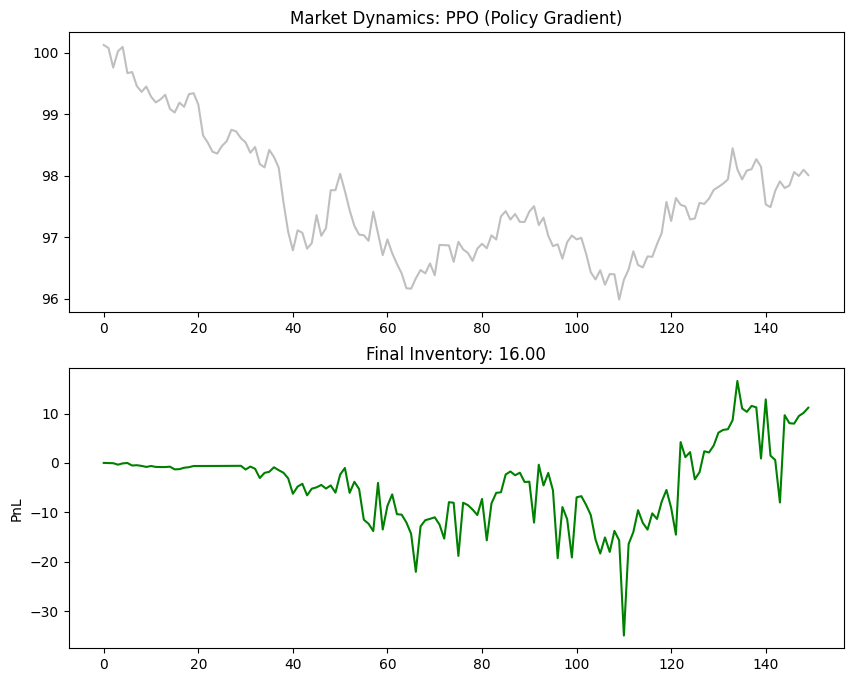

In [30]:
run_individual_sim("PPO", "PPO (Policy Gradient)")

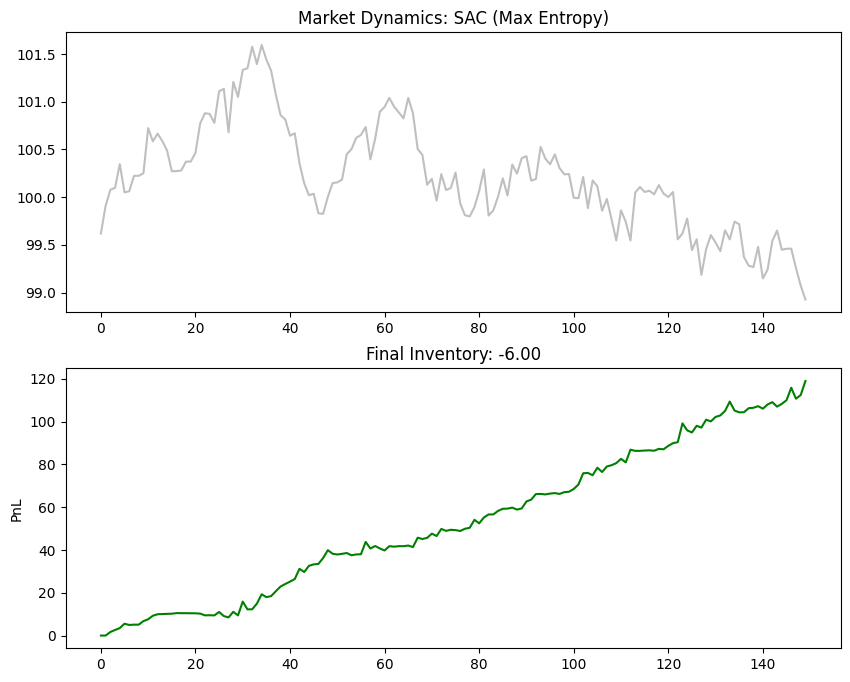

In [31]:
run_individual_sim("SAC", "SAC (Max Entropy)")

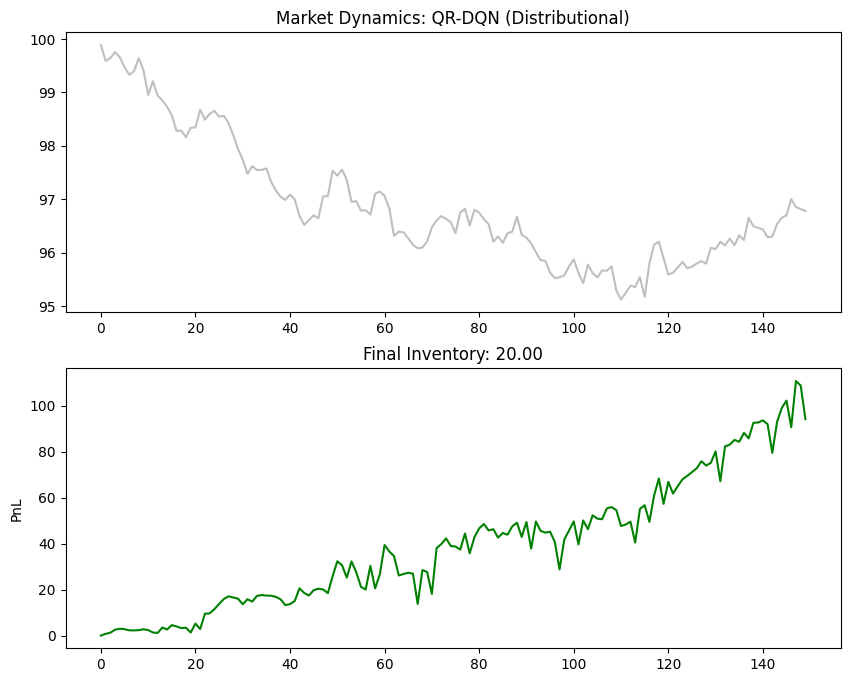

In [32]:
run_individual_sim("QR-DQN", "QR-DQN (Distributional)")

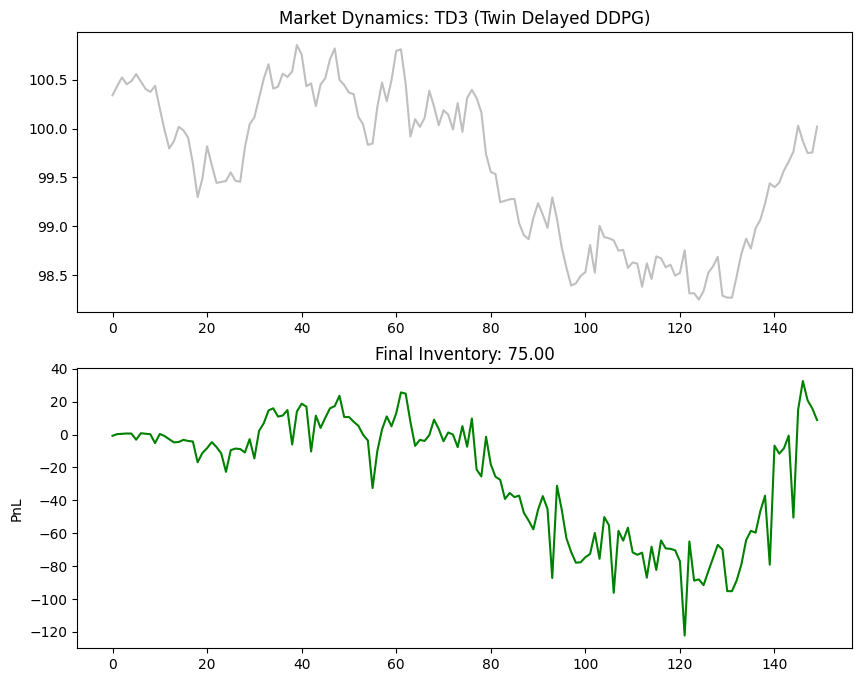

In [33]:
run_individual_sim("TD3", "TD3 (Twin Delayed DDPG)")

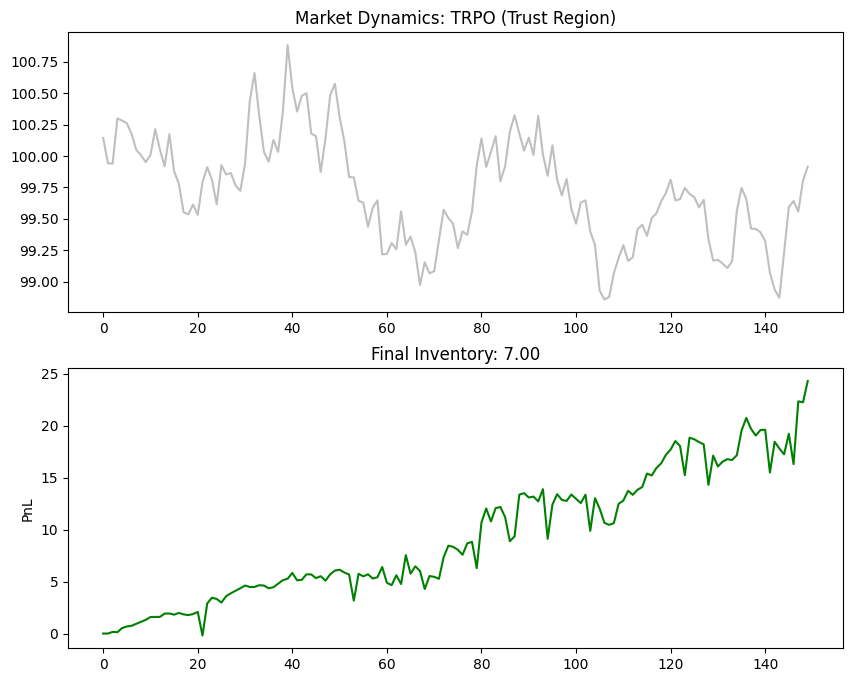

In [34]:
run_individual_sim("TRPO", "TRPO (Trust Region)")

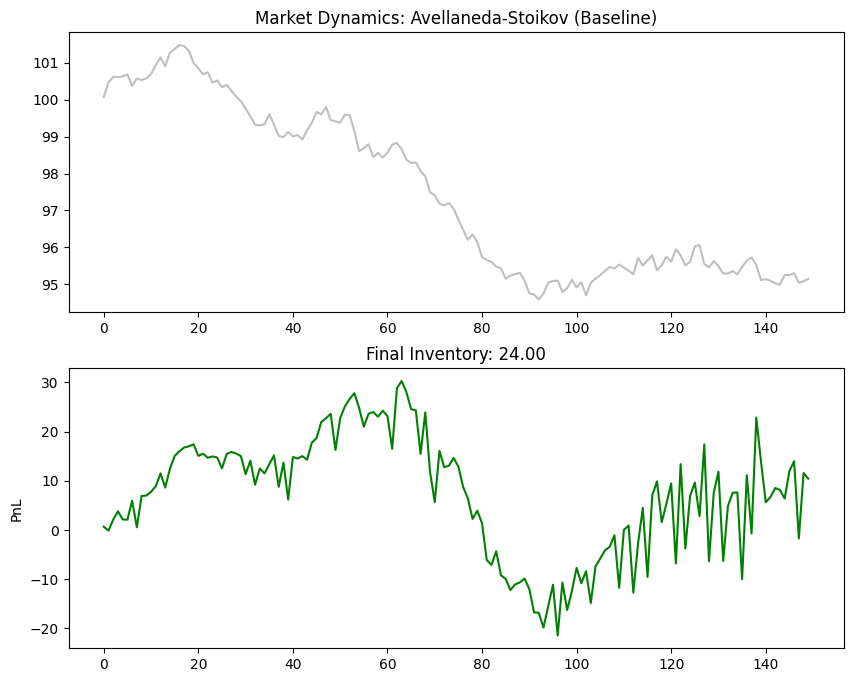

In [35]:
run_individual_sim("A&S", "Avellaneda-Stoikov (Baseline)")

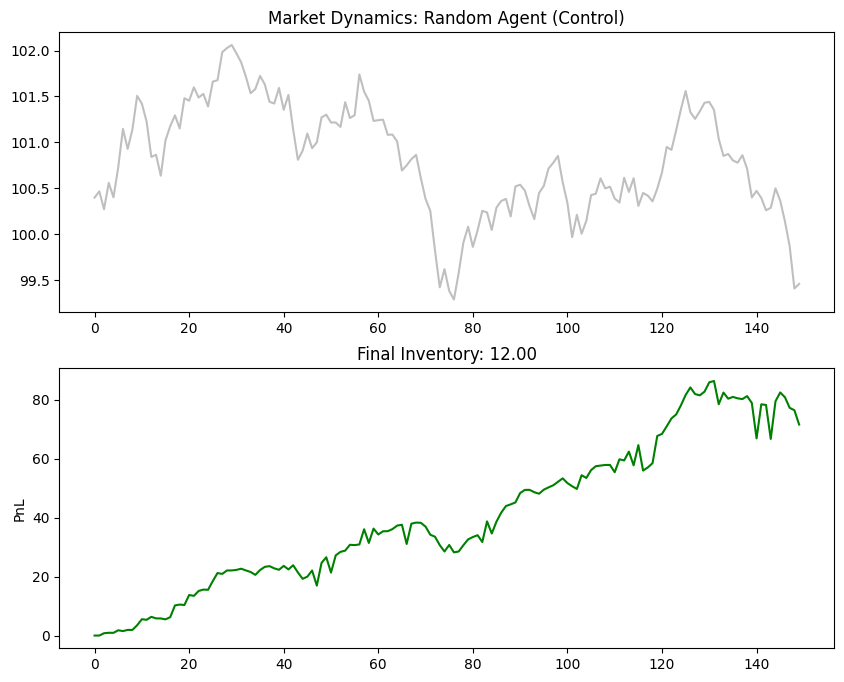

In [36]:
run_individual_sim("Random", "Random Agent (Control)")

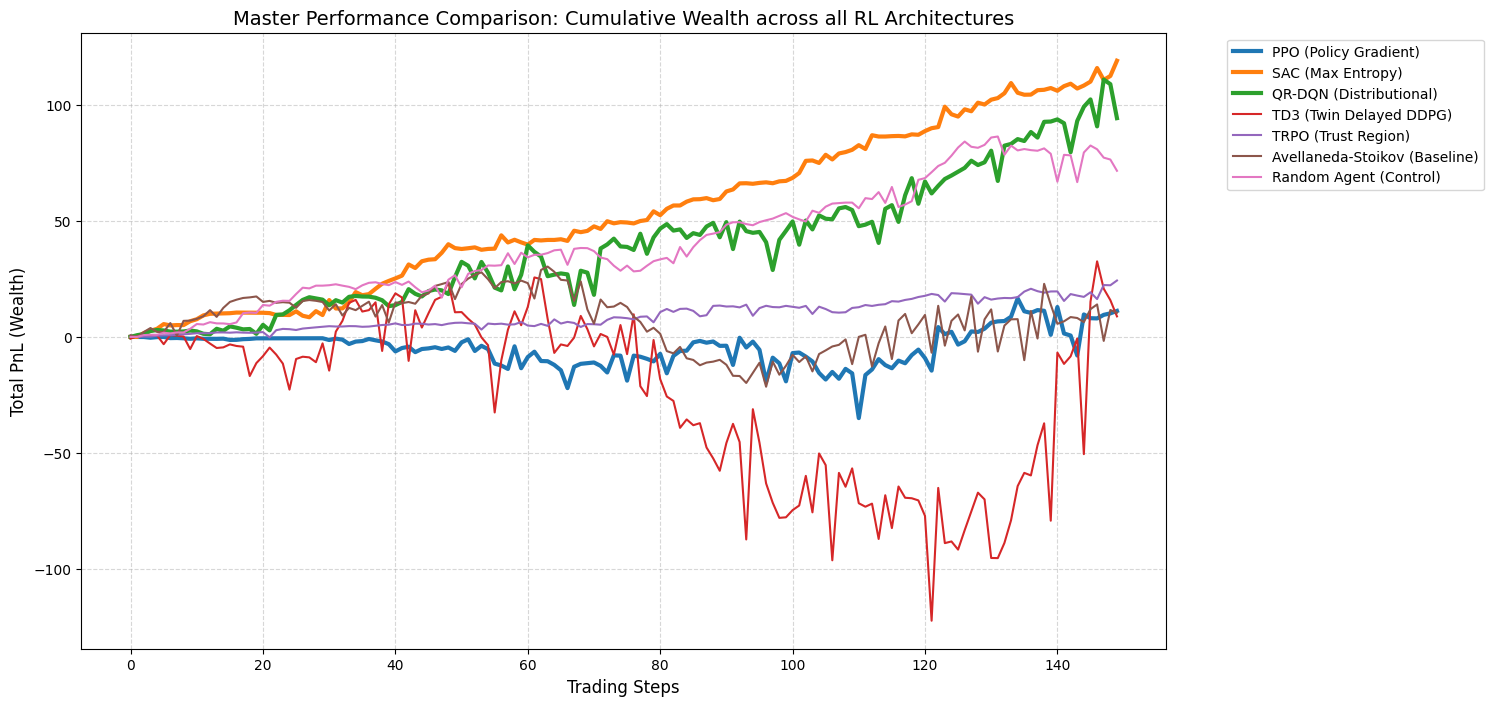

In [37]:
plt.figure(figsize=(14, 8))

for label, history in master_wealth_results.items():
    # Use thicker lines for primary algorithms [cite: 337-338]
    linewidth = 3 if any(x in label for x in ["SAC", "QR-DQN", "PPO"]) else 1.5
    plt.plot(history, label=label, linewidth=linewidth)

plt.title("Master Performance Comparison: Cumulative Wealth across all RL Architectures", fontsize=14)
plt.xlabel("Trading Steps", fontsize=12)
plt.ylabel("Total PnL (Wealth)", fontsize=12)

# Corrected Legend parameter
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()